In [3]:
#1. Import libraries & load data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/ecommerce_sales_data.csv")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 100000
Columns: 11


,Order ID,Product Name,Category,Price,Quantity,Total Sales,Customer ID,Customer Age,Customer Gender,Purchase Date,Purchase Time
0,261e3740-c0e9-42b1-bf87-881ac950fa3a,audience,Home & Garden,766.85,4,3067.40,81af1248-afff-46ee-a091-81cf33d0d957,39,Male,25/05/2024,6:28:14
1,0b332b34-46dc-4eaf-a808-fec7e97ffbc6,such,Clothing,331.42,4,1325.68,f3f3f4ac-7ad0-4362-9134-383096d16ac8,21,Male,04/05/2024,19:37:36
2,432e0b36-724d-4521-85ae-f66db8af8105,read,Clothing,708.10,10,7081.00,c4fc4269-3c1d-4b6b-ad23-d437c328d63f,27,Female,07/05/2024,17:54:42
3,ca20fb08-5c65-43b8-9577-3fa49913f93b,skill,Electronics,774.09,2,1548.18,578e2d1a-d92a-449d-8eeb-b704110b2975,51,Female,23/05/2024,22:31:43
4,1dce189c-8c60-455f-a6f2-69bb2cb71539,cold,Electronics,397.22,1,397.22,dc6ed196-0874-46bd-bbb9-c5534f619349,45,Female,15/03/2024,3:08:25


In [4]:
#2. Data inspection

print(df.info())
print(df.dtypes)
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Order ID         100000 non-null  object 
 1   Product Name     100000 non-null  object 
 2   Category         100000 non-null  object 
 3   Price            100000 non-null  float64
 4   Quantity         100000 non-null  int64  
 5   Total Sales      100000 non-null  float64
 6   Customer ID      100000 non-null  object 
 7   Customer Age     100000 non-null  int64  
 8   Customer Gender  100000 non-null  object 
 9   Purchase Date    100000 non-null  object 
 10  Purchase Time    100000 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 8.4+ MB
None
Order ID            object
Product Name        object
Category            object
Price              float64
Quantity             int64
Total Sales        float64
Customer ID         object
Customer Age         in

In [6]:
#3. Descriptive statistics

df.describe()
df.describe(include='object')

,Order ID,Product Name,Category,Customer ID,Customer Gender,Purchase Date,Purchase Time
count,100000,100000,100000,100000,100000,100000,100000
unique,100000,971,5,100000,2,156,59347
top,261e3740-c0e9-42b1-bf87-881ac950fa3a,fill,Clothing,81af1248-afff-46ee-a091-81cf33d0d957,Female,29/03/2024,8:42:36
freq,1,138,20144,1,50090,723,8


In [7]:
# 4. Data cleaning
df_clean = df.copy()

# Fix date/time columns
df_clean['Purchase Date'] = pd.to_datetime(df_clean['Purchase Date'], dayfirst=True)
df_clean['Purchase Time'] = pd.to_datetime(df_clean['Purchase Time'], format='%H:%M:%S').dt.time

# Remove extra spaces in text columns
for col in ['Product Name', 'Category', 'Customer Gender']:
    df_clean[col] = df_clean[col].str.strip()

# Remove duplicate rows
print("Duplicates found:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()

print("Shape after cleaning:", df_clean.shape)
df_clean.head()

Duplicates found: 0
Shape after cleaning: (100000, 11)


,Order ID,Product Name,Category,Price,Quantity,Total Sales,Customer ID,Customer Age,Customer Gender,Purchase Date,Purchase Time
0,261e3740-c0e9-42b1-bf87-881ac950fa3a,audience,Home & Garden,766.85,4,3067.40,81af1248-afff-46ee-a091-81cf33d0d957,39,Male,2024-05-25,06:28:14
1,0b332b34-46dc-4eaf-a808-fec7e97ffbc6,such,Clothing,331.42,4,1325.68,f3f3f4ac-7ad0-4362-9134-383096d16ac8,21,Male,2024-05-04,19:37:36
2,432e0b36-724d-4521-85ae-f66db8af8105,read,Clothing,708.10,10,7081.00,c4fc4269-3c1d-4b6b-ad23-d437c328d63f,27,Female,2024-05-07,17:54:42
3,ca20fb08-5c65-43b8-9577-3fa49913f93b,skill,Electronics,774.09,2,1548.18,578e2d1a-d92a-449d-8eeb-b704110b2975,51,Female,2024-05-23,22:31:43
4,1dce189c-8c60-455f-a6f2-69bb2cb71539,cold,Electronics,397.22,1,397.22,dc6ed196-0874-46bd-bbb9-c5534f619349,45,Female,2024-03-15,03:08:25


In [8]:
#5. Missing-value handling

missing = df_clean.isnull().sum()
print(missing)

if missing.sum() == 0:
    print("No missing values found in the dataset.")
else:
    # example: fill numeric with median, categorical with mode
    for col in df_clean.columns:
        if df_clean[col].isnull().sum() > 0:
            if df_clean[col].dtype in ['int64', 'float64']:
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            else:
                df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    print("Missing values handled.")
    print(df_clean.isnull().sum())

Order ID           0
Product Name       0
Category           0
Price              0
Quantity           0
Total Sales        0
Customer ID        0
Customer Age       0
Customer Gender    0
Purchase Date      0
Purchase Time      0
dtype: int64
No missing values found in the dataset.


                 Price  Quantity  Total Sales  Customer Age
Price         1.000000  0.004881     0.634558      0.005756
Quantity      0.004881  1.000000     0.701815      0.003164
Total Sales   0.634558  0.701815     1.000000      0.005630
Customer Age  0.005756  0.003164     0.005630      1.000000


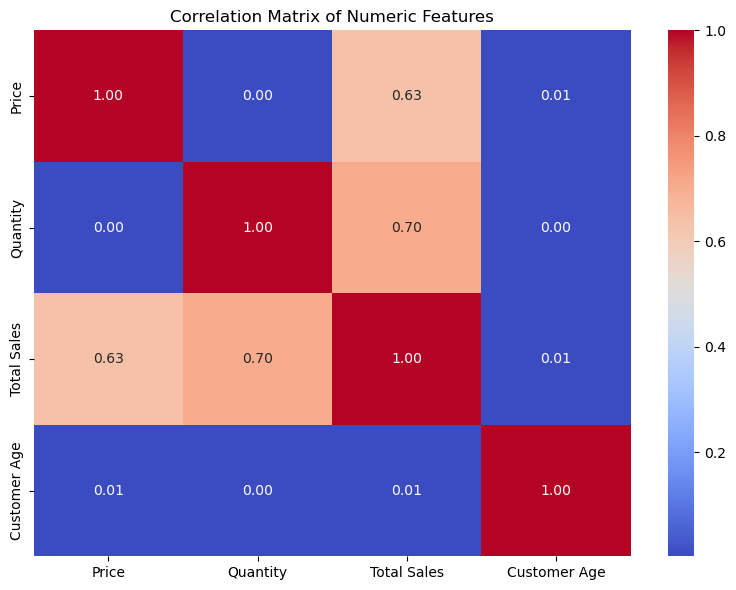

In [9]:
#6. Correlation analysis

numeric_cols = ['Price', 'Quantity', 'Total Sales', 'Customer Age']
corr_matrix = df_clean[numeric_cols].corr()
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [10]:
#7. Patterns and trends

category_sales = df_clean.groupby('Category')['Total Sales'].sum().sort_values(ascending=False)
print(category_sales)

df_clean['Month'] = df_clean['Purchase Date'].dt.to_period('M')
monthly_sales = df_clean.groupby('Month')['Total Sales'].sum()
print(monthly_sales)

gender_sales = df_clean.groupby('Customer Gender')['Total Sales'].sum()
print(gender_sales)

Category
Clothing         61071489.36
Books            60820086.17
Home & Garden    60670371.57
Toys             60274785.96
Electronics      59955937.12
Name: Total Sales, dtype: float64
Month
2024-01    59778158.05
2024-02    56363072.63
2024-03    60750883.75
2024-04    58328508.11
2024-05    59660466.02
2024-06     7911581.62
Freq: M, Name: Total Sales, dtype: float64
Customer Gender
Female    1.507956e+08
Male      1.519971e+08
Name: Total Sales, dtype: float64


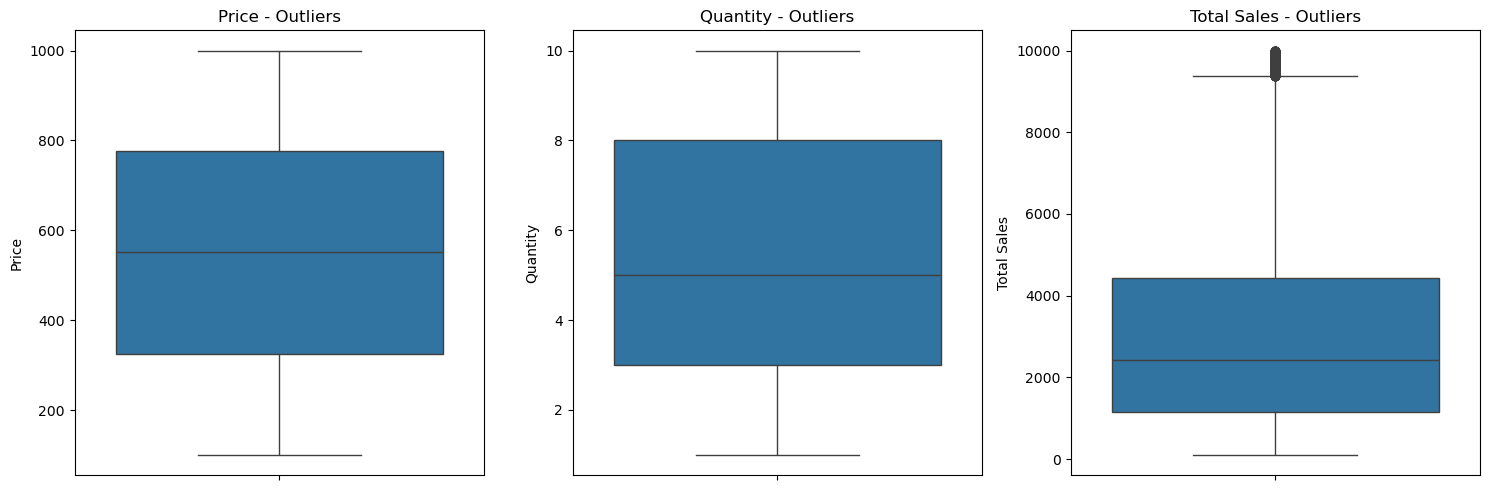

Outliers in Price: 0
Outliers in Quantity: 0
Outliers in Total Sales: 690


In [13]:
#8. Outlier identification

# Boxplots to spot outliers visually
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df_clean['Price'], ax=axes[0])
axes[0].set_title('Price - Outliers')

sns.boxplot(y=df_clean['Quantity'], ax=axes[1])
axes[1].set_title('Quantity - Outliers')

sns.boxplot(y=df_clean['Total Sales'], ax=axes[2])
axes[2].set_title('Total Sales - Outliers')

plt.tight_layout()
plt.show()

# IQR method to count outliers
def count_outliers(column):
    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[column] < lower) | (df_clean[column] > upper)]
    return len(outliers)

for col in ['Price', 'Quantity', 'Total Sales']:
    print(f"Outliers in {col}: {count_outliers(col)}")

In [ ]:
#9. Findings (add as a Markdown cell, not code)

## EDA Findings
- The dataset has [X] rows and [Y] columns with [Z] missing values (handled/none found).
- [Category name] generates the highest total sales.
- Sales peaked in [month] and were lowest in [month].
- Price and Quantity show a [weak/strong, positive/negative] correlation of [value].
- [Gender] customers contribute the most to total revenue.
- [N] outliers were detected in Total Sales, mainly from high-value bulk purchases.

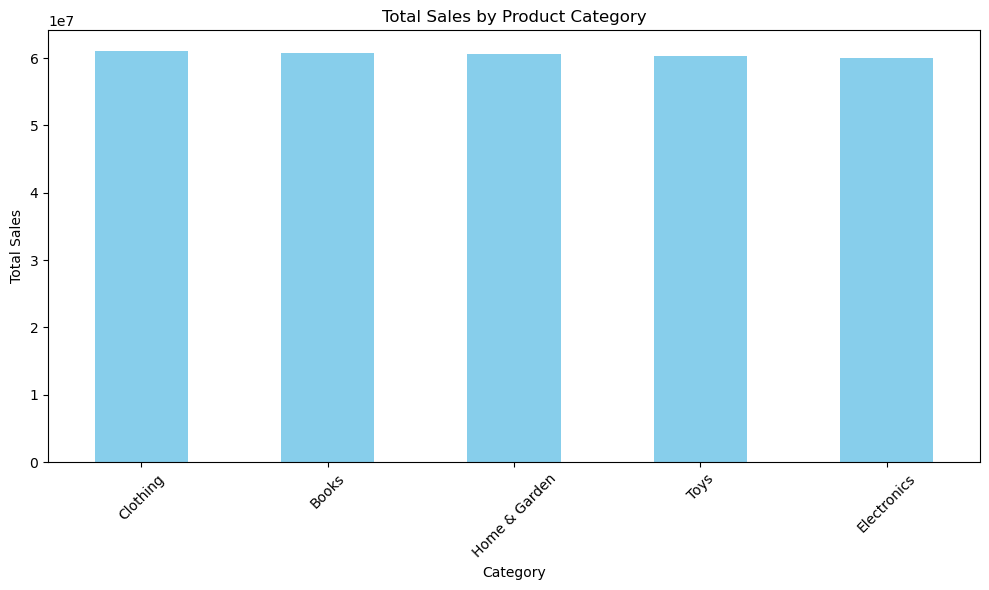

In [15]:
#TASK 5: Visualizations

#1. Bar chart — Sales by Category

plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

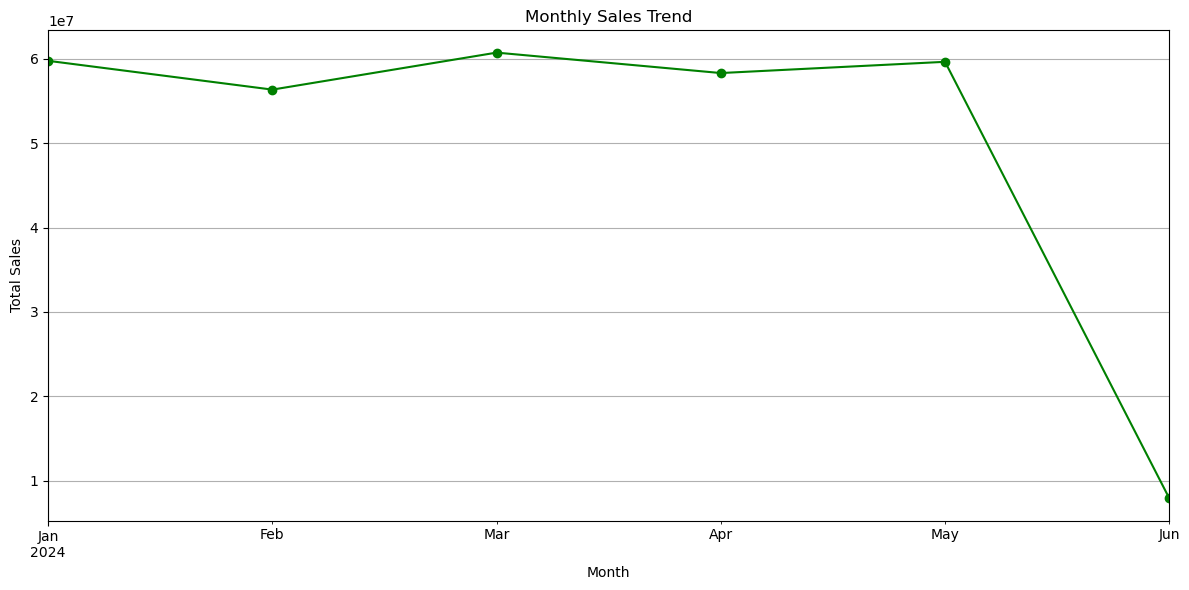

In [16]:
#2. Line chart — Monthly Sales Trend

plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.tight_layout()
plt.show()


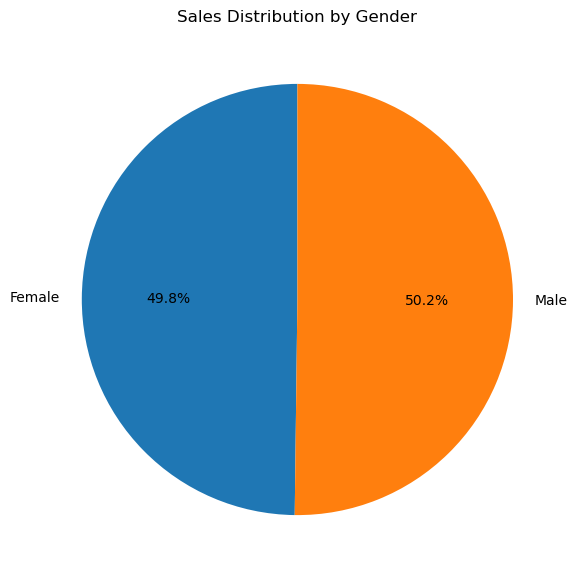

In [17]:
#3. Pie chart — Sales by Gender

plt.figure(figsize=(7, 7))
gender_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Gender')
plt.ylabel('')
plt.show()

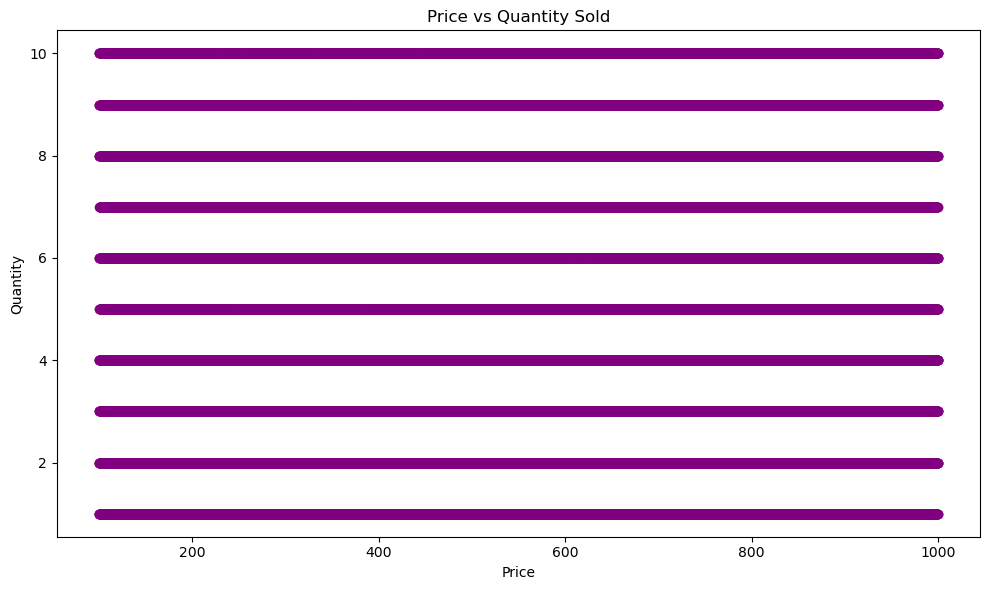

In [18]:
#4. Scatter plot — Price vs Quantity
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['Price'], df_clean['Quantity'], alpha=0.5, color='purple')
plt.title('Price vs Quantity Sold')
plt.xlabel('Price')
plt.ylabel('Quantity')
plt.tight_layout()
plt.show()

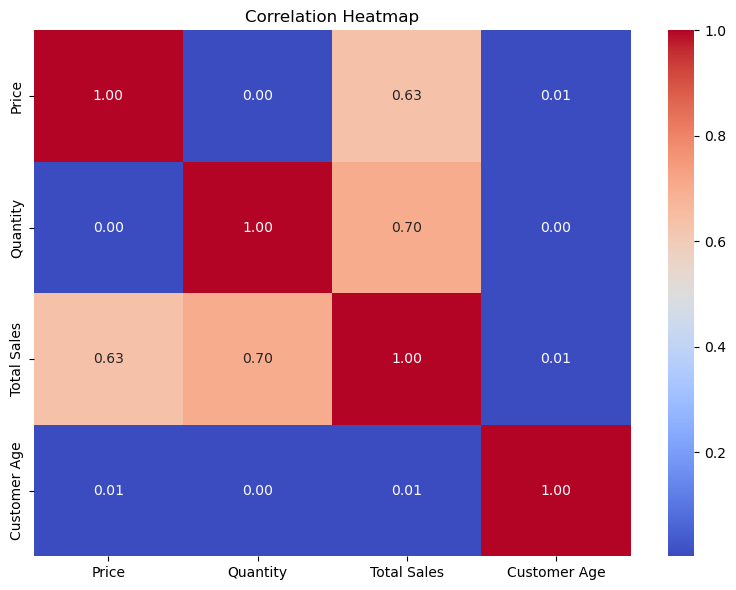

In [19]:
#5. Heatmap — Correlation (already made in Task 4 step 6, reuse it)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

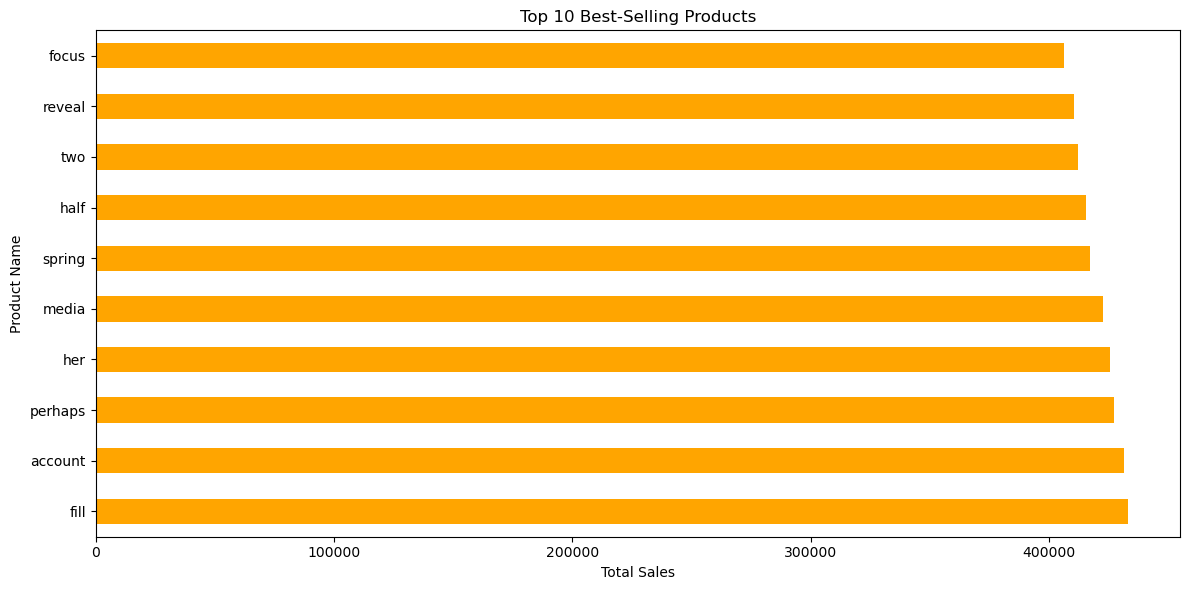

In [20]:
#6. Boxplot — Outliers (already made in Task 4 step 8, reuse it, or add one more chart type like this)

top_10_products = df_clean.groupby('Product Name')['Total Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_10_products.plot(kind='barh', color='orange')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()